### Buckley-Leverett PINN with artificial viscosity.

The Buckley--Leverett formulation with an added artificial viscosity term for immiscible, isothermal, horizontal two-phase flow, with the conservation equation for the wetting-phase saturation $S_w$, is defined as

$$\phi \frac{\partial S_{w}}{\partial t}+v\frac{\partial f(S_{w})}{\partial x}=\epsilon \frac{\partial^2 f(S_{w})}{\partial x^2},$$

subject to the conditions

$$S(0, t)=1 - S_{nr},$$

as the boundary condition, and

$$S(x, 0)=S_{wr},$$

as the initial condition.

Here, $\epsilon$ is the viscosity scaling factor, a numerical regularization term that helps diffuse the shock-type front.

For this approximation, the loss function model is constrained to the physics through the boundary and initial condition terms, such that

$$\mathcal{L} = \mathcal{L}_{physics}+\mathcal{L}_{\mathcal{I}}+\mathcal{L}_{\mathcal{B}}.$$

In [1]:
# Libraries
import numpy as np

# Matplotlib
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LinearLocator
from matplotlib import cm

import time
# Buckley-Leverett library
import BL as bl

# Tensorflow
import tensorflow as tf
from tensorflow.python.client import device_lib

In [12]:
# Physics Metaparameters
krwmax = 0.3      # Maximum relative permeability for water
nw = 2            # Saturation exponent for water
krnwmax = 0.8     # Maximum relative permeability for non-water (oil)
nnw = 2           # Saturation exponent for non-water (oil)
swc = 0.2         # Connate (irreducible) water saturation
snwr = 0.2        # Residual saturation of the non-water phase
muw = 1.0e-3      # Viscosity of water (Pa.s)
munw = 5.0e-3     # Viscosity of non-water phase (Pa.s)
qt = 0.1          # Flow rate (arbitrary units)
A = 1.0           # Cross-sectional area
phi = 0.2         # Porosity
l = 1.0           # Length of domain
t = 1.0           # Total time
Nx = 1000    # Spatial resolution
Nt = 1000    # Temporal resolution

times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] # Times for simulation (arbitrary units)

new_pred = np.zeros([Nt, Nx])

dt = t / Nt
dx = l / Nx

#### Initialize Brooks-Corey model

In [3]:
bc_model = bl.BrooksCorey(swc=swc, snwr=snwr, nw=nw, nnw=nnw,
                       krwmax=krwmax, krnwmax=krnwmax,
                       muw=muw, munw=munw)


Shock properties (Welge tangent):
  fw(swc): 0.0000
  Shock saturation (sw_tangent): 0.5542
  fw at shock: 0.7956
  Shock slope (alpha): 2.2463



In [4]:
# =============================================================================
# --------------------------  Collocation points   ----------------------------
# =============================================================================
print("Creating collocation points...")
x_col = np.linspace(0.001, l, 500).reshape(-1, 1)
t_col = np.linspace(0.00, max(times), 100).reshape(-1, 1)

X, T = np.meshgrid(x_col.flatten(), t_col.flatten(), indexing='ij')
X = tf.Variable(X.reshape(-1, 1), dtype=tf.float32)
T = tf.Variable(T.reshape(-1, 1), dtype=tf.float32)

print("Done!")
X_np = X.numpy()
T_np = T.numpy()

x_c = np.linspace(0,1,50).reshape(-1, 1)
y_c = np.linspace(0,1,50).reshape(-1, 1)
x_c, y_c = np.meshgrid(x_c.flatten(), y_c.flatten(), indexing='ij')

x_c_b = np.zeros(50)
y_c_b = np.linspace(0,1,50)

Creating collocation points...
Done!


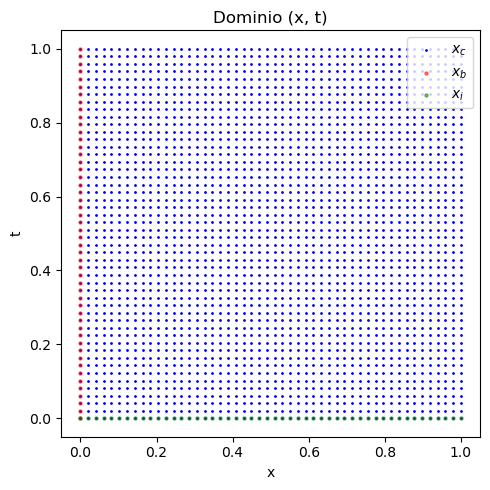

In [5]:
# Plot meshgrid
plt.figure(figsize=(5, 5))
plt.scatter(x_c, y_c , color='blue', s=1.0, alpha=1.0, label='$x_{c}$')
plt.scatter(x_c_b, y_c_b , color='red', s=5.0, alpha=0.5, label='$x_{b}$')
plt.scatter(y_c_b, x_c_b , color='green', s=5.0, alpha=0.5, label='$x_{i}$')
#if Use_data:
#    plt.scatter(x_data_flat[::2], t_data_flat[::2], color='red', s=0.2, alpha=0.5, label='$x_{d}$')
plt.xlabel("x")
plt.ylabel("t")
plt.title("Dominio (x, t)")
plt.legend()
plt.tight_layout()
plt.show()

#### Initialize PINN model

Here, we define the residual form of the governing PDE, which is enforced inside the loss function of the PINN model.

 $$\mathcal{L}(\theta)=\underbrace{\langle{\left(\phi \frac{d\hat{S_{w}}}{dt}+v\frac{df_{w}(\hat{S_{w}})}{dx}-\epsilon\frac{\partial^{2}\hat{S}_{w}}{\partial x^2}\right)}\rangle^{2}}_{\mathcal{L}_{physics}}
    +\underbrace{{(\hat{S_{w}}(x,0)-S_{wr})}^{2}}_{\mathcal{L}_{I}}+\underbrace{{(\hat{S}_{w}(0,t)-(1-S_{nr}))}^{2}}_{\mathcal{L}_{B}},$$

In [18]:
# PINN class
class PINN(tf.keras.Model):
    def __init__(self, neurons, layers, dim_in, dim_out):
        super(PINN, self).__init__() # Call methods from the mother class tf.keras.Model
        # Initial layer
        self.fci = tf.keras.layers.Dense(neurons, activation=None)
        # Output layer
        self.fco = tf.keras.layers.Dense(dim_out, activation=None)
        # Activation function
        self.tanh = tf.keras.layers.Activation('tanh')
        # Empty list for hidden layers
        self.mlps = []
        # Add hidden layers
        for _ in range(layers):
            self.mlps.append(tf.keras.layers.Dense(neurons, activation=None))
    
    def call(self, x, t):
        # Concatenate X and T
        x_i = tf.concat([x, t], axis=1)
        x_out = x_i # Create an output vector with the size of the input
        x_out = self.fci(x_out) # Evaluate x_i sequentaly using x_out
        
        for mlp_x in self.mlps:
            x_out = mlp_x(x_out)
            x_out = self.tanh(x_out)
        # Final x_out calculation
        x_out = self.fco(x_out)
        return x_out
        
# Physics loss function with artificial viscosity
def physics_informed_loss_diff(model, bc_model, x, t, qt, phi, A, epsilon=0.01):
    
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(t)
        
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(x)
            tape2.watch(t)
            
            # Predict saturation
            sw_pred = model(x, t)
            
            # Fractional flow calculation (no entropy fix needed)
            fw = bc_model.fractional_flow(sw_pred)
            
            # First derivative for second derivative computation
            sw_x = tape2.gradient(sw_pred, x)
        
        # Second derivative for artificial viscosity term
        sw_xx = tape.gradient(sw_x, x)
    
    # Compute time derivative and flux derivative
    sw_t = tape.gradient(sw_pred, t)
    fw_x = tape.gradient(fw, x)
    
    del tape
    
    # Buckley-Leverett equation with artificial viscosity
    # With artificial viscosity: ∂S/∂t + (qt/φA) * ∂f/∂x = ε * ∂²S/∂x²
    residual = sw_t + (qt / phi / A) * fw_x - epsilon * sw_xx
    
    # Initial condition: S(x, 0) = swc
    t_zero = tf.zeros_like(t)
    sw_initial = model(x, t_zero)
    
    # Boundary condition: S(0, t) = 1-snwr
    x_zero = tf.zeros_like(x)
    sw_boundary = model(x_zero, t)
    
    # Loss components
    loss_physics = tf.reduce_mean(tf.square(residual))
    loss_initial = tf.reduce_mean(tf.square(sw_initial - swc))
    loss_boundary = tf.reduce_mean(tf.square(sw_boundary - (1 - snwr)))
    
    total_loss = loss_physics + loss_boundary + loss_initial
    
    return total_loss, loss_physics, loss_boundary, loss_initial

In [19]:
# Instantiate the model
print("Initializing PINN model...")
model = PINN(neurons=64, layers=5, dim_in=2, dim_out=1)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

# Training
epochs_log = []
loss_totals = []
loss_physics_acc = []
loss_init_acc = []
loss_boundary_acc = []

num_epochs = 50000
print(f"\nStarting training for {num_epochs} epochs...\n")
staring_time = time.time()
for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        loss, loss_physics, loss_boundary, loss_initial = physics_informed_loss_diff(
            model, bc_model, X, T, qt, phi, A, 0.001
        )
    
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    if epoch % 500 == 0 or epoch + 1 == num_epochs:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.numpy():.5f}, "
              f"Physics: {loss_physics.numpy():.5f}, "
              f"Initial: {loss_initial.numpy():.5f}, "
              f"Boundary: {loss_boundary.numpy():.5f}")
    """
    if loss.numpy() <= 0.001:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.numpy():.5f}, "
              f"Physics: {loss_physics.numpy():.5f}, "
              f"Initial: {loss_initial.numpy():.5f}, "
              f"Boundary: {loss_boundary.numpy():.5f}")
        break
    """
    epochs_log.append(epoch)
    loss_totals.append(loss.numpy())
    loss_physics_acc.append(loss_physics.numpy())
    loss_init_acc.append(loss_initial.numpy())
    loss_boundary_acc.append(loss_boundary.numpy())

print("\nTraining complete!")
print("Training time = %1.5f"%((time.time()-staring_time)/60.0))

Initializing PINN model...

Starting training for 50000 epochs...

Epoch 0/50000, Loss: 0.68507, Physics: 0.00054, Initial: 0.03045, Boundary: 0.65409
Epoch 500/50000, Loss: 0.02396, Physics: 0.00654, Initial: 0.01252, Boundary: 0.00490
Epoch 1000/50000, Loss: 0.01831, Physics: 0.00610, Initial: 0.00925, Boundary: 0.00296
Epoch 1500/50000, Loss: 0.01552, Physics: 0.00507, Initial: 0.00861, Boundary: 0.00184
Epoch 2000/50000, Loss: 0.01429, Physics: 0.00266, Initial: 0.01022, Boundary: 0.00141
Epoch 2500/50000, Loss: 0.01697, Physics: 0.00526, Initial: 0.01054, Boundary: 0.00117
Epoch 3000/50000, Loss: 0.01622, Physics: 0.00447, Initial: 0.01070, Boundary: 0.00105
Epoch 3500/50000, Loss: 0.01146, Physics: 0.00402, Initial: 0.00627, Boundary: 0.00117
Epoch 4000/50000, Loss: 0.01079, Physics: 0.00361, Initial: 0.00615, Boundary: 0.00103
Epoch 4500/50000, Loss: 0.01191, Physics: 0.00276, Initial: 0.00826, Boundary: 0.00089
Epoch 5000/50000, Loss: 0.01282, Physics: 0.00338, Initial: 0.00857

In [6]:
# Create test points
x_test = np.linspace(0, l, Nx)
profile_pred = []

In [ ]:
for i, t_val in enumerate(times):
    x_plot = tf.constant(x_test, dtype=tf.float32)
    x_plot = tf.reshape(x_plot, (-1, 1))
    t_plot = tf.fill(tf.shape(x_plot), t_val)
    S_pred = model(x_plot, t_plot).numpy()
    profile_pred.append(S_pred)

In [23]:
x_test = np.linspace(0, l, Nx)
dt = 1 / Nt
u_pred = np.zeros([Nt, Nx])
starting_time = time.time()
for i in range(Nt):
    t_val = i * dt
    x_plot = tf.constant(x_test, dtype=tf.float32)
    x_plot = tf.reshape(x_plot, (-1, 1))
    t_plot = tf.fill(tf.shape(x_plot), t_val)
    u_pred[i] = model(x_plot, t_plot).numpy().reshape(Nx,)
print((time.time()-starting_time)/60.0)

0.04566941261291504


#### Calculation of the semi-analytical solution

In [7]:
semi = bl.analytic_solution(Swc=swc, Sor=snwr, krw0=krwmax, kro0=krnwmax, nw=nw, no=nnw,
                         mu_w=muw, mu_o=munw, Nx=Nx, Nt=Nt, A=A, qt=qt, phi=phi,
                         fw_tangent = bc_model.fw_tangent, sw_tangent = bc_model.sw_tangent,
                         L=l, T=l)
u = semi.create_solution()

#### Comparison between the PINN model and the semi-analytical solution

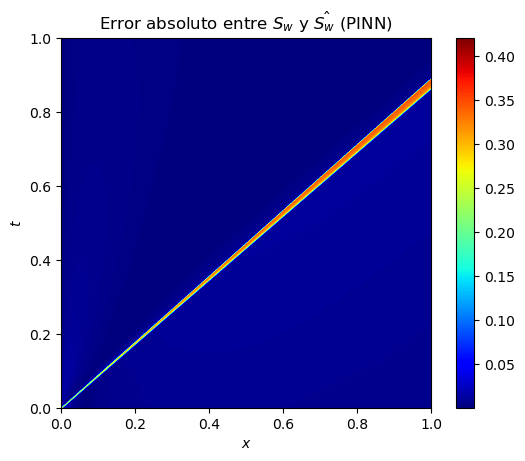

In [28]:
absolute_error = np.abs(np.array(u_pred)-np.array(u))

plt.figure()
plt.imshow(absolute_error, cmap="jet", extent=[0, 1, 0, 1], origin='lower')
plt.xlabel("$x$")
plt.ylabel("$t$")
plt.title("Error absoluto entre $S_{w}$ y $\hat{S_{w}}$ (PINN)")
plt.colorbar()
plt.show()

In [33]:
np.mean(absolute_error)

0.009650984940833478

#### Save and load the Buckley-Leverett simple trained model

In [34]:
# Save trained model
folder_name = 'model_viscosity'
model.save(folder_name, save_format='tf')

INFO:tensorflow:Assets written to: model_viscosity\assets


In [35]:
np.savetxt(f'model_viscosity'+"/"+"total_loss.csv",
           np.array(loss_totals).reshape(-1,1), delimiter=',') 
np.savetxt(f'model_viscosity'+"/"+"physics_loss.csv",
           np.array(loss_physics_acc).reshape(-1,1), delimiter=',') 
np.savetxt(f'model_viscosity'+"/"+"init_loss.csv",
           np.array(loss_init_acc).reshape(-1,1), delimiter=',') 
np.savetxt(f'model_viscosity'+"/"+"boundary_loss.csv",
           np.array(loss_boundary_acc).reshape(-1,1), delimiter=',') 

In [9]:
# Load and compile trained model
folder_name = 'model_viscosity'
new_model = tf.keras.models.load_model(folder_name)
new_model.compile()

In [13]:
new_pred = np.zeros([Nt, Nx])

for i in range(Nt):
    t_val = i * dt
    x_plot = tf.constant(x_test, dtype=tf.float32)
    x_plot = tf.reshape(x_plot, (-1, 1))
    t_plot = tf.fill(tf.shape(x_plot), t_val)
    new_pred[i] = new_model(x_plot, t_plot).numpy().reshape(Nx,)

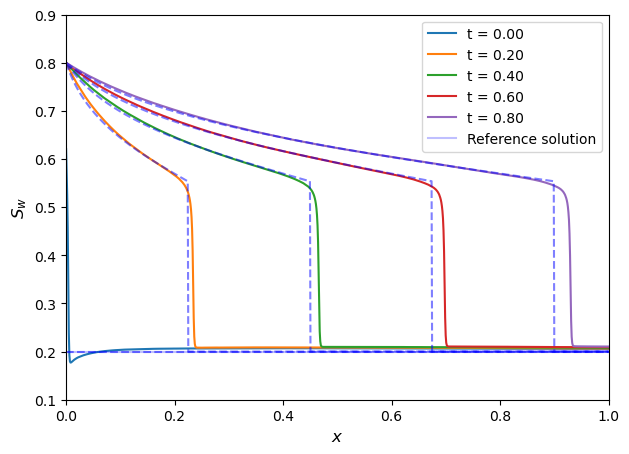

In [14]:
j = 0
plt.figure(figsize=[7,5])

for i in range(Nt):
    if i%(Nt/5) == 0:
        plt.plot(x_test, new_pred[i], label=f't = {i*dt:.2f}')
        plt.plot(x_test, u[i], "b--",alpha=0.5)
        if j < len(new_pred):
            j += 1
plt.plot(x_test, u[0], "b-",alpha=0.25, label="Reference solution")
plt.xlabel("$x$", fontsize=12)
plt.ylabel("$S_{w}$", fontsize=12)
plt.ylim([0.1, 0.9])
plt.xlim([0,1])
plt.legend()
# plt.savefig("Figure6a.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
import pandas as pd
df = pd.read_csv("model_viscosity/total_loss.csv", header=None)

In [21]:
loss_totals = df.values
epochs_log = np.arange(len(loss_totals))

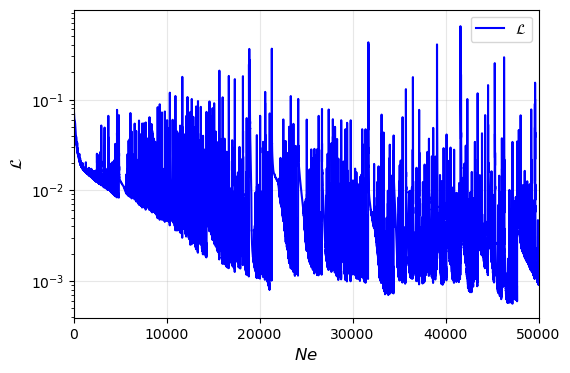

In [22]:
plt.figure(figsize=[6,4])
# Training loss
plt.plot(epochs_log, loss_totals, 'b-', label='$\mathcal{L}$')
plt.ylabel('$\mathcal{L}$', fontsize=12)
plt.xlabel('$Ne$', fontsize=12)
plt.yscale('log')
plt.legend()
plt.xlim(0,len(loss_totals))
plt.xlabel("$Ne$",fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()